### <u><B> *XGBOOST*</B></U>

XGBoost (Extreme Gradient Boosting) is a supervised ensemble learning algorithm that builds a strong predictive model by sequentially adding small, regularized decision trees, where each new tree is trained using the first- and second-order gradients of a loss function to correct the errors made by previous trees, while controlling overfitting through explicit regularization and optimized tree-splitting.

*XGBoost = Gradient Boosting + Regularization + Second-order optimization + System-level efficiency*

In [2]:
from sklearn.datasets import load_breast_cancer

In [5]:
data=load_breast_cancer()
X=data.data
y=data.target
X

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
from xgboost import XGBClassifier


In [11]:
xgbc=XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    gamma=0.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_jobs=-1,
    random_state=42,
    tree_method="hist"
)

<u> *#objective="binary:logistic"*</u> tells XGBoost that the task is binary classification and that it should optimize the logistic (log‑loss) objective and output probabilities via a sigmoid.

Regression: use objective="reg:squarederror" (or similar) to model continuous targets instead of probabilities.

<u> reg_lambda (L2) and reg_alpha (L1)</u>
Meaning: L2 (reg_lambda) and L1 (reg_alpha) regularization on leaf weights.​

Effect:

reg_lambda: shrinks weights, smooths model.

reg_alpha: can push some weights to zero (sparsity).​



In [12]:
xgbc.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [13]:
y_pred=xgbc.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy: ",accuracy_score(y_test,y_pred))
print("Classification report: ", classification_report(y_test,y_pred))

Accuracy:  0.956140350877193
Classification report:                precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



##### COMPUTE ROC CURVE:

ROC Curve = a graph

AUC = area under that graph

It evaluates how well a binary classifier separates classes across all possible thresholds.

In [15]:
from sklearn.metrics import roc_auc_score,roc_curve

In [ ]:
# You must pass only the positive-class probability:
y_prob=xgbc.predict_proba(X_test)[:,1]

In [19]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)

In [20]:
auc=roc_auc_score(y_test,y_prob)

In [21]:
print("AUC SCORE: ", auc)

AUC SCORE:  0.9934490664919751


C:\Users\Admin\AppData\Local\Temp\ipykernel_2836\2890607887.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


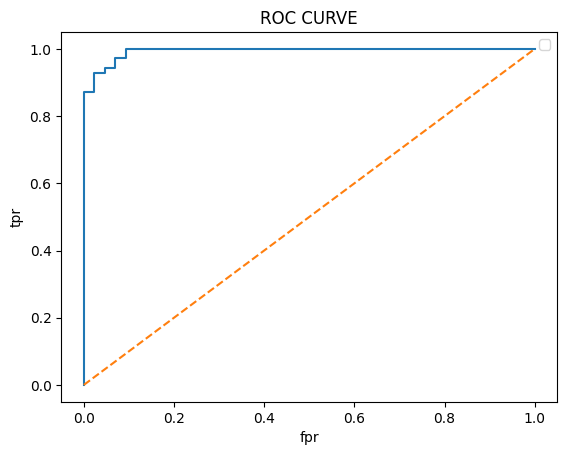

In [22]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("ROC CURVE")
plt.legend()
plt.show()